# Mood Embedder: GloVe-Based Mood Detection

This notebook demonstrates the `MoodEmbedder` module, which uses GloVe 100d word vectors and spaCy tokenization to detect mood/atmosphere signals in free-text recipe prompts.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from pantry.mood_embedder import MoodEmbedder, MOOD_VOCABULARY

In [2]:
embedder = MoodEmbedder()

## 1. Mood Vocabulary by Category

In [3]:
MOOD_CATEGORIES = {
    "Cozy/Warm": ["cozy", "warm", "comfort", "comforting", "homey", "hearty"],
    "Elegant": ["elegant", "fancy", "sophisticated", "refined", "classy"],
    "Rustic": ["rustic", "simple", "humble", "traditional", "classic"],
    "Fresh": ["fresh", "light", "bright", "vibrant", "zesty"],
    "Rich": ["rich", "indulgent", "decadent", "luxurious", "creamy"],
    "Spicy": ["spicy", "bold", "fiery", "intense", "hot"],
    "Healthy": ["healthy", "clean", "nutritious", "wholesome", "lean"],
    "Festive": ["festive", "celebration", "party", "special", "holiday"],
    "Romantic": ["romantic", "intimate", "date"],
    "Casual": ["lazy", "relaxed", "chill", "casual"],
    "Adventurous": ["adventurous", "exotic", "unusual", "creative", "fun"],
    "Seasonal": ["rainy", "cold", "winter", "summer", "autumn", "spring"],
}

for category, words in MOOD_CATEGORIES.items():
    print(f"{category:15s}: {', '.join(words)}")
print(f"\nTotal mood words: {len(MOOD_VOCABULARY)}")

Cozy/Warm      : cozy, warm, comfort, comforting, homey, hearty
Elegant        : elegant, fancy, sophisticated, refined, classy
Rustic         : rustic, simple, humble, traditional, classic
Fresh          : fresh, light, bright, vibrant, zesty
Rich           : rich, indulgent, decadent, luxurious, creamy
Spicy          : spicy, bold, fiery, intense, hot
Healthy        : healthy, clean, nutritious, wholesome, lean
Festive        : festive, celebration, party, special, holiday
Romantic       : romantic, intimate, date
Casual         : lazy, relaxed, chill, casual
Adventurous    : adventurous, exotic, unusual, creative, fun
Seasonal       : rainy, cold, winter, summer, autumn, spring

Total mood words: 59


## 2. Mood Token Extraction on Example Prompts

In [4]:
prompts = [
    "cozy evening dinner for two",
    "something elegant for a date night",
    "quick and healthy weeknight meal",
    "bold and spicy Thai curry",
    "rustic Italian comfort food",
    "light and fresh summer salad",
    "rich decadent chocolate dessert",
    "festive holiday dinner party",
    "lazy Sunday brunch",
    "adventurous exotic street food",
    "warm hearty soup for a cold rainy day",
    "simple clean eating lunch",
]

print(f"{'Prompt':<45s} {'Mood Tokens':<35s} {'Has Vector'}")
print("-" * 90)
for prompt in prompts:
    result = embedder.embed(prompt)
    tokens_str = ", ".join(result["mood_tokens"]) if result["mood_tokens"] else "(none)"
    has_vec = result["vector"] is not None
    print(f"{prompt:<45s} {tokens_str:<35s} {has_vec}")

Prompt                                        Mood Tokens                         Has Vector
------------------------------------------------------------------------------------------
cozy evening dinner for two                   cozy                                True
something elegant for a date night            elegant, date, night                True
quick and healthy weeknight meal              healthy                             True
bold and spicy Thai curry                     bold, spicy                         True
rustic Italian comfort food                   rustic, comfort                     True
light and fresh summer salad                  light, fresh, summer                True
rich decadent chocolate dessert               rich, decadent                      True
festive holiday dinner party                  festive, holiday, party             True
lazy Sunday brunch                            lazy                                True
adventurous exotic street food   

## 3. Nearest-Neighbor Words for Key Mood Tokens

For selected mood words, we show the 5 closest words in the GloVe vocabulary.

In [5]:
key_words = ["cozy", "elegant", "spicy", "fresh", "romantic", "rustic", "festive", "healthy"]

for word in key_words:
    neighbors = embedder._glove.most_similar(word, topn=5)
    neighbor_str = ", ".join(f"{w} ({s:.3f})" for w, s in neighbors)
    print(f"{word:12s} -> {neighbor_str}")

cozy         -> cosy (0.752), comfy (0.681), homey (0.660), cramped (0.646), dingy (0.645)
elegant      -> stylish (0.825), graceful (0.773), sleek (0.761), luxurious (0.742), sumptuous (0.731)
spicy        -> tangy (0.807), delicious (0.791), savory (0.752), peppery (0.744), flavorful (0.742)
fresh        -> amid (0.673), dried (0.644), add (0.627), bring (0.625), mix (0.618)
romantic     -> romance (0.812), tale (0.713), melodrama (0.711), musical (0.695), erotic (0.691)
rustic       -> picturesque (0.674), quaint (0.672), elegant (0.670), homey (0.662), unpretentious (0.644)
festive      -> joyous (0.743), celebratory (0.720), festivities (0.696), holiday (0.686), celebrations (0.667)
healthy      -> healthier (0.728), good (0.680), better (0.679), stable (0.677), mature (0.667)


## 4. t-SNE Visualization of Mood Vocabulary Embeddings

We project the 100d GloVe vectors of all mood vocabulary words into 2D using t-SNE, colored by category.

Embedding matrix shape: (59, 100) (12 categories)


/var/folders/t4/_5k32b150815791rjdt0gtcr0000gp/T/ipykernel_53748/935457953.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_cats))


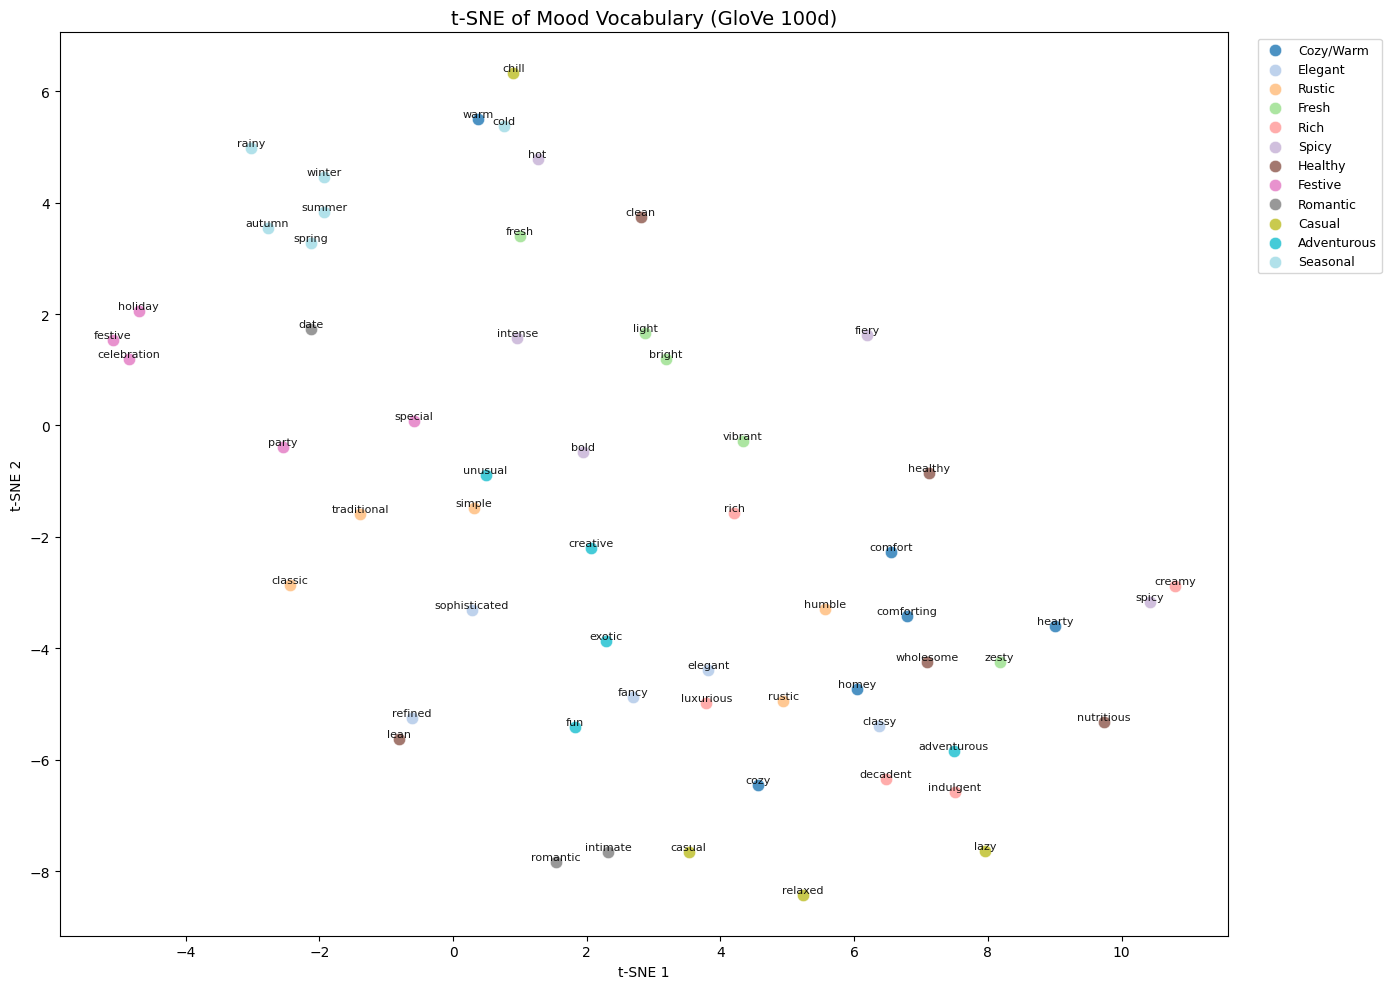

Saved to data/mood_tsne.png


In [6]:
# Collect vectors and labels by category
words_list = []
vectors_list = []
categories_list = []

for category, words in MOOD_CATEGORIES.items():
    for word in words:
        if word in embedder._glove:
            words_list.append(word)
            vectors_list.append(embedder._glove[word])
            categories_list.append(category)

X = np.array(vectors_list)
print(f"Embedding matrix shape: {X.shape} ({len(set(categories_list))} categories)")

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(X) - 1))
X_2d = tsne.fit_transform(X)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
unique_cats = list(MOOD_CATEGORIES.keys())
cmap = plt.cm.get_cmap("tab20", len(unique_cats))

for i, cat in enumerate(unique_cats):
    mask = [c == cat for c in categories_list]
    idxs = [j for j, m in enumerate(mask) if m]
    ax.scatter(
        X_2d[idxs, 0], X_2d[idxs, 1],
        c=[cmap(i)], label=cat, s=80, alpha=0.8, edgecolors="white", linewidth=0.5
    )
    for j in idxs:
        ax.annotate(
            words_list[j], (X_2d[j, 0], X_2d[j, 1]),
            fontsize=8, ha="center", va="bottom", alpha=0.9
        )

ax.set_title("t-SNE of Mood Vocabulary (GloVe 100d)", fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("../data/mood_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/mood_tsne.png")